In this notebook, we use the climate model FaIR ([Finite amplitude Impulse Response simple climate model](https://docs.fairmodel.net/en/latest/)) to estimate the contribution of non-CO2 greenhouse gasses to histrical warming and warming in climate change scenarios. We then convert these temperature trajectories to an equivalent 'Carbon Airtime' timeseries by assuming a constant Carbon Climate Response (CCR).

In [40]:
pip install FAIR

In [41]:
# Import auxilarry packages and choose basic FaIR parameters
import numpy as np
import matplotlib.pyplot as pl
import pandas as pd

from fair import FAIR
from fair.io import read_properties
from fair.interface import fill, initialise
from fair.earth_params import seconds_per_year

In [42]:
#Choose method for simulating effect of methane (CH_4)
f = FAIR(ch4_method='thornhill2021')

In [43]:
#Set start and end years for simulation and choose scenarios
yr0=1750
#yr1=2150
yr1=2500
f.define_time(yr0, yr1, 1)
scenarios = ['ssp119','ssp126', 'ssp245','ssp370','ssp585']
f.define_scenarios(scenarios)

In [44]:
#Load data underpinning FaIR simulations
df = pd.read_csv("https://raw.githubusercontent.com/OMS-NetZero/FAIR/master/tests/test_data/4xCO2_cummins_ebm3.csv")
models = df['model'].unique()
configs = []

for imodel, model in enumerate(models):
    for run in df.loc[df['model']==model, 'run']:
        configs.append(f"{model}_{run}")
f.define_configs(configs)

In [45]:
#Set species and initialise model
species, properties = read_properties()
f.define_species(species, properties)
f.allocate()
f.fill_species_configs()
fill(f.species_configs['unperturbed_lifetime'], 10.8537568, specie='CH4')
fill(f.species_configs['baseline_emissions'], 19.01978312, specie='CH4')
fill(f.species_configs['baseline_emissions'], 0.08602230754, specie='N2O')

f.fill_from_rcmip()
initialise(f.concentration, f.species_configs['baseline_concentration'])
initialise(f.forcing, 0)
initialise(f.temperature, 0)
initialise(f.cumulative_emissions, 0)
initialise(f.airborne_emissions, 0)

In [46]:
# Set parameters of model
seed = 1355763

for config in configs:
    model, run = config.split('_')
    condition = (df['model']==model) & (df['run']==run)
    fill(f.climate_configs['ocean_heat_capacity'], df.loc[condition, 'C1':'C3'].values.squeeze(), config=config)
    fill(f.climate_configs['ocean_heat_transfer'], df.loc[condition, 'kappa1':'kappa3'].values.squeeze(), config=config)
    fill(f.climate_configs['deep_ocean_efficacy'], df.loc[condition, 'epsilon'].values[0], config=config)
    fill(f.climate_configs['gamma_autocorrelation'], df.loc[condition, 'gamma'].values[0], config=config)
    fill(f.climate_configs['sigma_eta'], df.loc[condition, 'sigma_eta'].values[0], config=config)
    fill(f.climate_configs['sigma_xi'], df.loc[condition, 'sigma_xi'].values[0], config=config)
    fill(f.climate_configs['stochastic_run'], True, config=config)
    fill(f.climate_configs['use_seed'], True, config=config)
    fill(f.climate_configs['seed'], seed, config=config)

    seed = seed + 399

In [47]:
# Set CO2 forcing to zero
CO2_emissions = np.zeros([yr1-yr0,len(scenarios),66])
#CO2_emissions.shape
fill(f.emissions, CO2_emissions, specie="CO2 FFI")
CO2A_emissions = np.zeros([yr1-yr0,len(scenarios),66])
#CO2A_emissions.shape
fill(f.emissions, CO2A_emissions, specie="CO2 AFOLU")
# Toggle on to remove CH4
#CH4_emissions = np.zeros([yr1-yr0,len(scenarios),66])+19.01978312
#CO2A_emissions.shape
#fill(f.emissions, CH4_emissions, specie="CH4")

In [48]:
# Run FaIR
f.run()

Running 330 projections in parallel:   0%|          | 0/750 [00:00<?, ?timesteps/s]

Text(0, 0.5, 'W/m2')

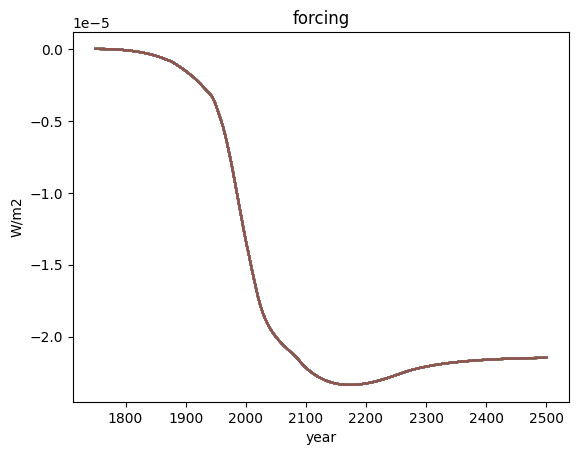

In [49]:
pl.plot(f.timebounds, f.forcing.loc[dict(scenario='ssp126', specie='CO2')], label=f.configs);
pl.title('forcing')
pl.xlabel('year')
pl.ylabel('W/m2')

Text(0, 0.5, 'W/m2')

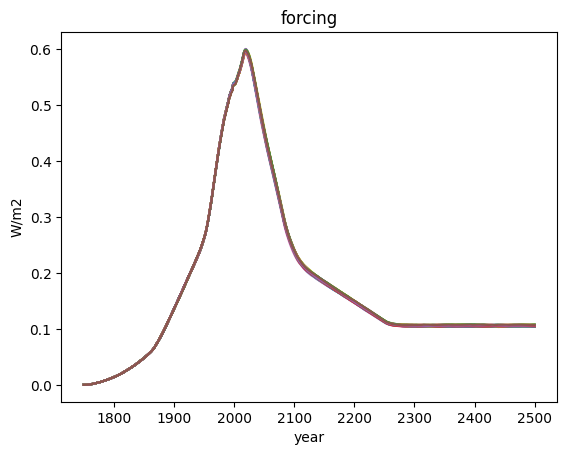

In [50]:
pl.plot(f.timebounds, f.forcing.loc[dict(scenario='ssp126', specie='CH4')], label=f.configs);
pl.title('forcing')
pl.xlabel('year')
pl.ylabel('W/m2')

Text(0, 0.5, 'W/m2')

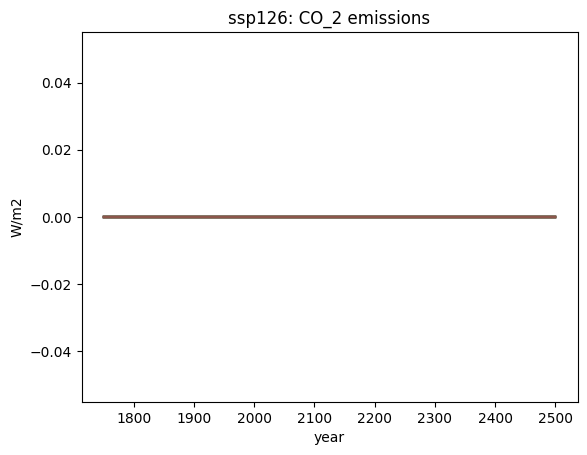

In [51]:
pl.plot(f.timepoints, f.emissions.loc[dict(scenario='ssp126', specie='CO2')], label=f.configs);
pl.title('ssp126: CO_2 emissions')
pl.xlabel('year')
pl.ylabel('W/m2')

Text(0, 0.5, 'Temperature anomaly (K)')

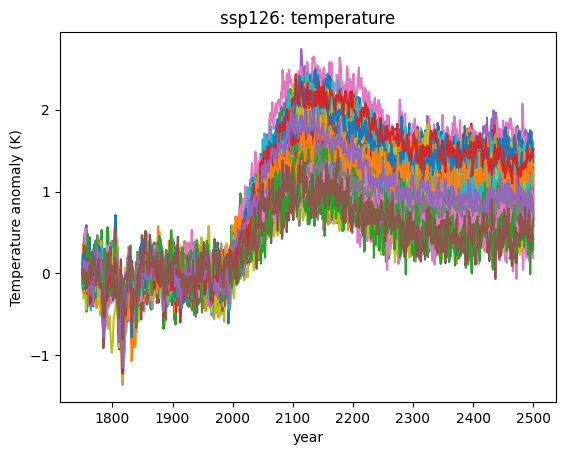

In [52]:
pl.plot(f.timebounds, f.temperature.loc[dict(scenario='ssp585', layer=0)], label=f.configs);
pl.title('ssp126: temperature')
pl.xlabel('year')
pl.ylabel('Temperature anomaly (K)')

In [53]:
f.temperature.loc[dict(scenario='ssp585', layer=0)].mean(dim="config")

<xarray.DataArray (timebounds: 751)> Size: 6kB
array([ 0.00000000e+00,  1.73905099e-02,  5.07183659e-02,  6.99843505e-02,
        5.23250709e-02,  5.02550366e-02,  3.34918497e-02,  8.80352116e-03,
        1.89392236e-02,  5.75690650e-02,  6.90087874e-02,  7.18631477e-02,
        3.60633814e-02, -8.82853031e-02, -8.48759544e-02, -4.99161586e-02,
       -4.66795788e-02, -1.09519154e-01, -8.15518326e-02, -2.88743126e-02,
        1.68222396e-02,  1.76574622e-02,  5.36946475e-02,  5.01425145e-02,
        6.44737020e-02,  8.06113287e-02,  5.87849385e-02,  7.61734801e-02,
        8.57447514e-02,  5.56163057e-02,  5.83303962e-02,  9.33445718e-02,
        1.01763385e-01,  1.05730151e-03, -3.15411747e-01, -5.53769594e-01,
       -5.22463059e-01, -3.79983888e-01, -2.71702906e-01, -1.49739419e-01,
       -9.18070955e-02, -7.10062613e-02, -3.31446042e-02, -2.49917275e-03,
        7.55964365e-03,  1.83192436e-02, -4.42182943e-03, -2.07991743e-02,
       -3.56346263e-02, -1.70739107e-02, -1.28382741e-02,  6.29682057e-03,
        1.71354442e-02,  1.15082193e-02,  6.70894731e-02,  8.31030136e-02,
        8.46119485e-02,  8.27829361e-02,  7.78300833e-02, -1.51196113e-01,
       -5.02156228e-01, -5.60116827e-01, -4.57306678e-01, -3.22917719e-01,
       -2.02261561e-01, -3.81712968e-01, -8.04383582e-01, -9.75424521e-01,
       -8.00555500e-01, -6.35846638e-01, -4.65984842e-01, -3.55987732e-01,
       -2.97762115e-01, -2.98496346e-01, -2.71440854e-01, -2.10075965e-01,
       -1.49626366e-01, -9.51194891e-02, -6.79432184e-02, -5.69914755e-02,
...
        9.48768996e-01,  9.57139492e-01,  9.60819741e-01,  9.69926265e-01,
        9.71436096e-01,  9.69134960e-01,  9.98692423e-01,  1.00171855e+00,
        9.96865538e-01,  9.98792919e-01,  9.85131155e-01,  9.90451803e-01,
        1.00430227e+00,  9.83931535e-01,  9.94645835e-01,  1.00325970e+00,
        9.84151263e-01,  9.81868100e-01,  9.71382245e-01,  9.67743776e-01,
        9.62570196e-01,  9.65147839e-01,  9.62228695e-01,  9.74448155e-01,
        9.64867846e-01,  9.74807114e-01,  9.89176136e-01,  9.87963419e-01,
        9.78390975e-01,  9.86573954e-01,  9.88825451e-01,  9.65731209e-01,
        9.80710249e-01,  9.80325228e-01,  9.55602806e-01,  9.63043455e-01,
        1.00766864e+00,  1.00423196e+00,  9.54934905e-01,  9.68021626e-01,
        9.79465659e-01,  9.83765345e-01,  9.61061821e-01,  9.47039117e-01,
        9.44762553e-01,  9.19907494e-01,  9.55169159e-01,  9.48592994e-01,
        9.52696762e-01,  9.72724674e-01,  9.13921151e-01,  9.42331305e-01,
        9.55046480e-01,  9.39123042e-01,  9.44273383e-01,  9.43777376e-01,
        9.51709472e-01,  9.41374512e-01,  9.60260737e-01,  9.72453130e-01,
        9.91240988e-01,  9.79536789e-01,  9.76171641e-01,  9.74901427e-01,
        9.70605097e-01,  9.84537100e-01,  9.65742383e-01,  9.46501056e-01,
        9.39624744e-01,  9.44609377e-01,  9.70888314e-01,  9.78577187e-01,
        9.70667749e-01,  9.74972115e-01,  9.61418086e-01,  9.62731658e-01,
        9.51806858e-01,  9.38345256e-01,  9.64757052e-01])
Coordinates:
  * timebounds  (timebounds) float64 6kB 1.75e+03 1.751e+03 ... 2.5e+03
    scenario    <U6 24B 'ssp585'
    layer       int64 8B 0

(np.float64(1750.0), np.float64(2000.0), np.float64(-0.3), np.float64(0.3))

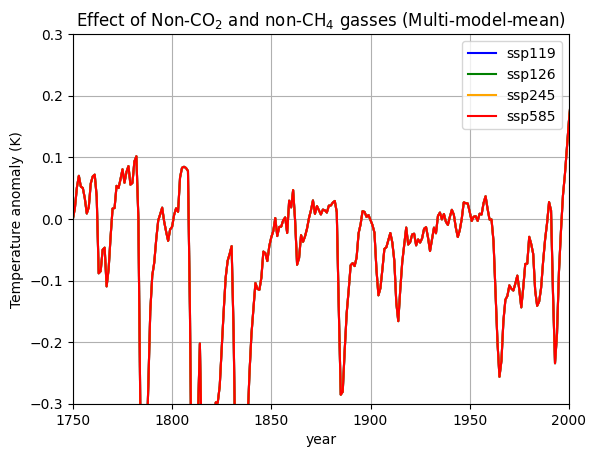

In [54]:
pl.plot(f.timebounds, f.temperature.loc[dict(scenario='ssp119', layer=0)].mean(dim='config'),'b',label='ssp119');
pl.plot(f.timebounds, f.temperature.loc[dict(scenario='ssp126', layer=0)].mean(dim='config'),'g',label='ssp126');
pl.plot(f.timebounds, f.temperature.loc[dict(scenario='ssp245', layer=0)].mean(dim='config'),'orange',label='ssp245');
pl.plot(f.timebounds, f.temperature.loc[dict(scenario='ssp585', layer=0)].mean(dim='config'),'r',label='ssp585');

#pl.title('Effect of Non-CO$_2$ and non-CH$_4$ gasses (Multi-model-mean)')
pl.title('Effect of Non-CO$_2$ and non-CH$_4$ gasses (Multi-model-mean)')
pl.xlabel('year')
pl.ylabel('Temperature anomaly (K)')
pl.legend()
pl.grid()
pl.axis([1750,2000,-0.3,0.3])

(np.float64(1750.0), np.float64(2000.0), np.float64(-0.3), np.float64(0.3))

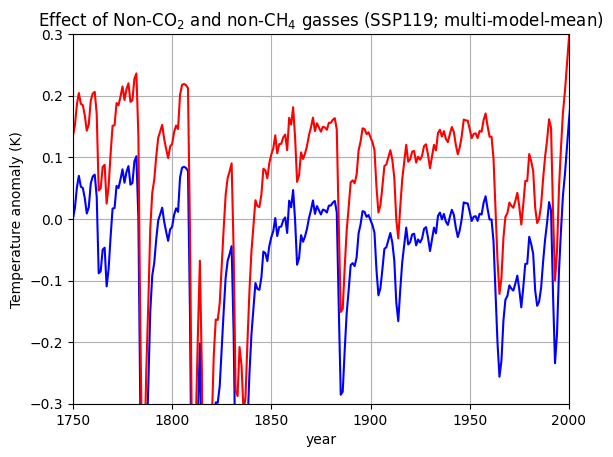

In [55]:
pl.plot(f.timebounds, f.temperature.loc[dict(scenario='ssp119', layer=0)].mean(dim='config'),'b',label='Anomaly from 1750');
preIndMean = f.temperature.loc[dict(scenario='ssp119', layer=0)][f.timebounds<1850].mean(dim='config').mean(dim='timebounds')
pl.plot(f.timebounds, f.temperature.loc[dict(scenario='ssp119', layer=0)].mean(dim='config')-preIndMean,'r',label='Anomaly from <1850 mean');

#pl.title('Effect of Non-CO$_2$ and non-CH$_4$ gasses (Multi-model-mean)')
pl.title('Effect of Non-CO$_2$ and non-CH$_4$ gasses (SSP119; multi-model-mean)')
pl.xlabel('year')
pl.ylabel('Temperature anomaly (K)')
pl.grid()
pl.axis([1750,2000,-0.3,0.3])

(np.float64(1750.0), np.float64(2100.0), np.float64(-15.0), np.float64(100.0))

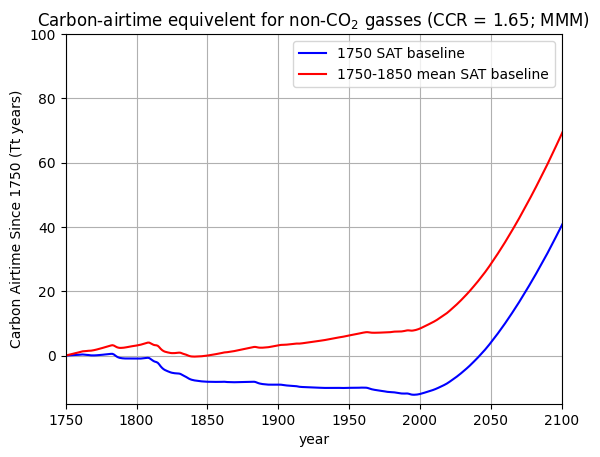

In [56]:
CCR = 1.65;
yr1 = 1750

cum_emiss_eq=f.temperature.loc[dict(scenario='ssp585', layer=0)].mean(dim='config')/CCR
CATe = np.cumsum(cum_emiss_eq[f.timebounds>yr1])
pl.plot(f.timebounds[f.timebounds>yr1], CATe,'b',label='1750 SAT baseline');

cum_emiss_eq2=(f.temperature.loc[dict(scenario='ssp585', layer=0)].mean(dim='config')-preIndMean)/CCR
CATe2 = np.cumsum(cum_emiss_eq2[f.timebounds>yr1])
pl.plot(f.timebounds[f.timebounds>yr1], CATe2,'r',label='1750-1850 mean SAT baseline');

pl.title('Carbon-airtime equivelent for non-CO$_2$ gasses (CCR = 1.65; MMM)')
#pl.title('non-CO$_2$ and non-CH$_4$ Carbon Airtime equiv. (CCR = 1.5; MMM)')

pl.xlabel('year')
pl.ylabel('Carbon Airtime Since 1750 (Tt years)')
pl.legend()
pl.grid()
pl.axis([1750,2100,-15,100])

(np.float64(1750.0), np.float64(2000.0), np.float64(-20.0), np.float64(20.0))

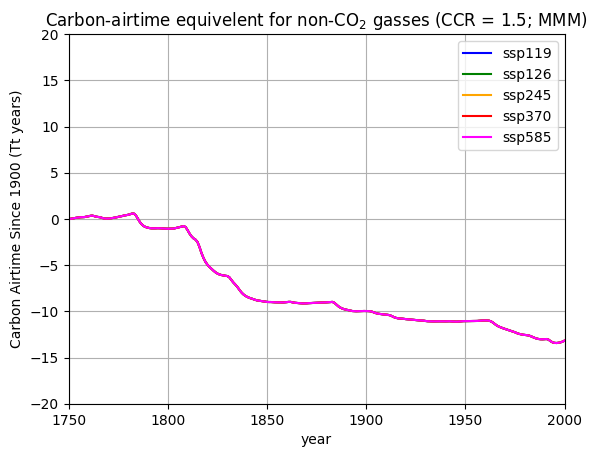

In [26]:
CCR = 1.5;
yr1 = 1750

cum_emiss_eq=f.temperature.loc[dict(scenario='ssp119', layer=0)].mean(dim='config')/CCR
CATe = np.cumsum(cum_emiss_eq[f.timebounds>yr1])
pl.plot(f.timebounds[f.timebounds>yr1], CATe,'b',label='ssp119');

cum_emiss_eq=f.temperature.loc[dict(scenario='ssp126', layer=0)].mean(dim='config')/CCR
CATe = np.cumsum(cum_emiss_eq[f.timebounds>yr1])
pl.plot(f.timebounds[f.timebounds>yr1], CATe,'g',label='ssp126');

cum_emiss_eq=f.temperature.loc[dict(scenario='ssp245', layer=0)].mean(dim='config')/CCR
CATe = np.cumsum(cum_emiss_eq[f.timebounds>yr1])
pl.plot(f.timebounds[f.timebounds>yr1], CATe,'orange',label='ssp245');

cum_emiss_eq=f.temperature.loc[dict(scenario='ssp370', layer=0)].mean(dim='config')/CCR
CATe = np.cumsum(cum_emiss_eq[f.timebounds>yr1])
pl.plot(f.timebounds[f.timebounds>yr1], CATe,'red',label='ssp370');

cum_emiss_eq=f.temperature.loc[dict(scenario='ssp585', layer=0)].mean(dim='config')/CCR
CATe = np.cumsum(cum_emiss_eq[f.timebounds>yr1])
pl.plot(f.timebounds[f.timebounds>yr1], CATe,'magenta',label='ssp585');

pl.title('Carbon-airtime equivelent for non-CO$_2$ gasses (CCR = 1.5; MMM)')
#pl.title('non-CO$_2$ and non-CH$_4$ Carbon Airtime equiv. (CCR = 1.5; MMM)')

pl.xlabel('year')
pl.ylabel('Carbon Airtime Since 1900 (Tt years)')
pl.legend()
pl.grid()
pl.axis([1750,2000,-20,20])

In [63]:
offset=preIndMean
#offset = 0#Toggle to zero in case of setting 1750 as offset.
fair_pd = pd.DataFrame({'Year': f.timebounds,\
        'temp_ssp119': f.temperature.loc[dict(scenario='ssp119', layer=0)].mean(dim='config')-offset,
        'temp_ssp126': f.temperature.loc[dict(scenario='ssp126', layer=0)].mean(dim='config')-offset,
        'temp_ssp245': f.temperature.loc[dict(scenario='ssp245', layer=0)].mean(dim='config')-offset,
        'temp_ssp370': f.temperature.loc[dict(scenario='ssp370', layer=0)].mean(dim='config')-offset,
        'temp_ssp585': f.temperature.loc[dict(scenario='ssp585', layer=0)].mean(dim='config')-offset})

In [64]:
display(fair_pd)

,Year,temp_ssp119,temp_ssp126,temp_ssp245,temp_ssp370,temp_ssp585
0,1750.0,0.134420,0.134420,0.134420,0.134420,0.134420
1,1751.0,0.151811,0.151811,0.151811,0.151811,0.151811
2,1752.0,0.185139,0.185139,0.185139,0.185139,0.185139
3,1753.0,0.204405,0.204405,0.204405,0.204405,0.204405
4,1754.0,0.186745,0.186745,0.186745,0.186745,0.186745
...,...,...,...,...,...,...
746,2496.0,0.741012,0.751644,0.859477,1.777093,1.095838
747,2497.0,0.742535,0.753153,0.860909,1.778784,1.097152
748,2498.0,0.731818,0.742422,0.850103,1.768235,1.086227
749,2499.0,0.718563,0.729152,0.836759,1.755150,1.072766


<Axes: xlabel='Year'>

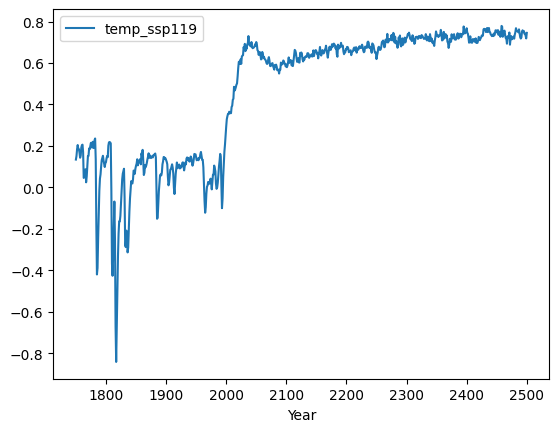

In [65]:
fair_pd.plot(x='Year',y='temp_ssp119')

In [19]:
#%%bash
# Mounting requires a special 'bash' command
#!git clone https://github.com/janzika/TimeInAir.git

In [20]:
#Save FaIR output to github
#fair_pd.to_csv("./TimeInAir/FAIR_NON_CO2_GHGs_SIMULATION_v5.csv")

In [68]:

from google.colab import drive
drive.mount('/content/drive')
fair_pd.to_csv('FAIR_NON_CO2_GHGs_SIMULATION_17501850_offset.csv')
!cp FAIR_NON_CO2_GHGs_SIMULATION_17501850_offset.csv "/content/drive/My Drive/"
!fusermount -u /content/drive


Mounted at /content/drive
